In [ ]:
#Recall
# من بين كل الزجاجات المعيبة الموجودة فعلاً، كم واحدة نجح النظام في صيدها?

# Precision
# من بين كل الزجاجات التي قال عنها النظام أنها (معيبة)، كم واحدة منها كانت معيبة فعلاً؟

#AUC - Area Under Curve
# قدرة النموذج على ترتيب الصور بحيث تأخذ الصور المعيبة سكوراً أعلى من السليمة دائماً.

# F1-Score
# مزيج بين Precision و Recall، يعطيك فكرة عن الأداء العام للنموذج في

# accuracy
# نسبة الصور التي تم تصنيفها بشكل صحيح سواء كانت سليمة أو معيبة من إجمالي الصور.

In [10]:
import pandas as pd

df = pd.read_csv('anomaly_detection_results/grid_test/others/all_categories_grid_search.csv')
df.sort_values(by='F1', ascending=False, inplace=True)
df.head(20)

,Category,Strength,Guidance,AUC,Precision,Recall,F1,Accuracy,Threshold
85,capsule,0.48,9.0,0.7112,0.8868,0.8624,0.8744,0.7955,0.1968
120,capsule,0.55,10.0,0.6765,0.8785,0.8624,0.8704,0.7879,0.2049
119,capsule,0.55,9.5,0.6781,0.8785,0.8624,0.8704,0.7879,0.2057
11,capsule,0.32,5.0,0.6653,0.9239,0.7798,0.8458,0.7652,0.1794
12,capsule,0.32,5.5,0.6741,0.9231,0.7706,0.8400,0.7576,0.1795
56,capsule,0.40,9.0,0.7172,0.8958,0.7890,0.8390,0.7500,0.1949
67,capsule,0.42,9.0,0.7172,0.8958,0.7890,0.8390,0.7500,0.1949
27,capsule,0.35,7.5,0.7535,0.9130,0.7706,0.8358,0.7500,0.1852
159,toothbrush,0.35,9.0,0.4583,0.7250,0.9667,0.8286,0.7143,0.2061
160,toothbrush,0.35,9.5,0.4639,0.7250,0.9667,0.8286,0.7143,0.2086


In [ ]:
import pandas as pd

num_good = 20
num_defect = 63
total_samples = num_good + num_defect

df = pd.read_csv('anomaly_detection_results/grid_search_results.csv')

# F1 = 2 * (Precision * Recall) / (Precision + Recall)
df['F1_Score'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'])

def calculate_accuracy(row):
    if row['Precision'] == 0:
        return 0  # Zero accuracy if precision is zero to avoid division by zero
    
    tp = row['Recall'] * num_defect
    
    fp = (tp / row['Precision']) - tp
    
    tn = max(0, num_good - fp)
    
    return (tp + tn) / total_samples

df['Accuracy'] = df.apply(calculate_accuracy, axis=1)

df_sorted = df.sort_values(by='F1_Score', ascending=False)

df_sorted.to_csv('anomaly_detection_results/grid_search_results_updated.csv', index=False)

# top 10
df_sorted[['Strength', 'Guidance', 'Recall', 'Precision', 'F1_Score', 'Accuracy']].head(10)

     Strength  Guidance  Recall  Precision  F1_Score  Accuracy
56       0.42       5.5  0.9048     0.8382  0.870228  0.795170
45       0.40       5.5  0.9048     0.8382  0.870228  0.795170
30       0.35       9.0  0.8095     0.8644  0.836050  0.759015
40       0.38       8.5  0.8095     0.8644  0.836050  0.759015
38       0.38       7.5  0.8095     0.8644  0.836050  0.759015
95       0.50       8.5  0.7619     0.9231  0.834789  0.771097
106      0.52       8.5  0.7619     0.9231  0.834789  0.771097
28       0.35       8.0  0.7937     0.8621  0.826487  0.747044
37       0.38       7.0  0.7937     0.8621  0.826487  0.747044
36       0.38       6.5  0.7937     0.8621  0.826487  0.747044


✅ تم حفظ الرسم البياني المعدل بفاصل 0.1


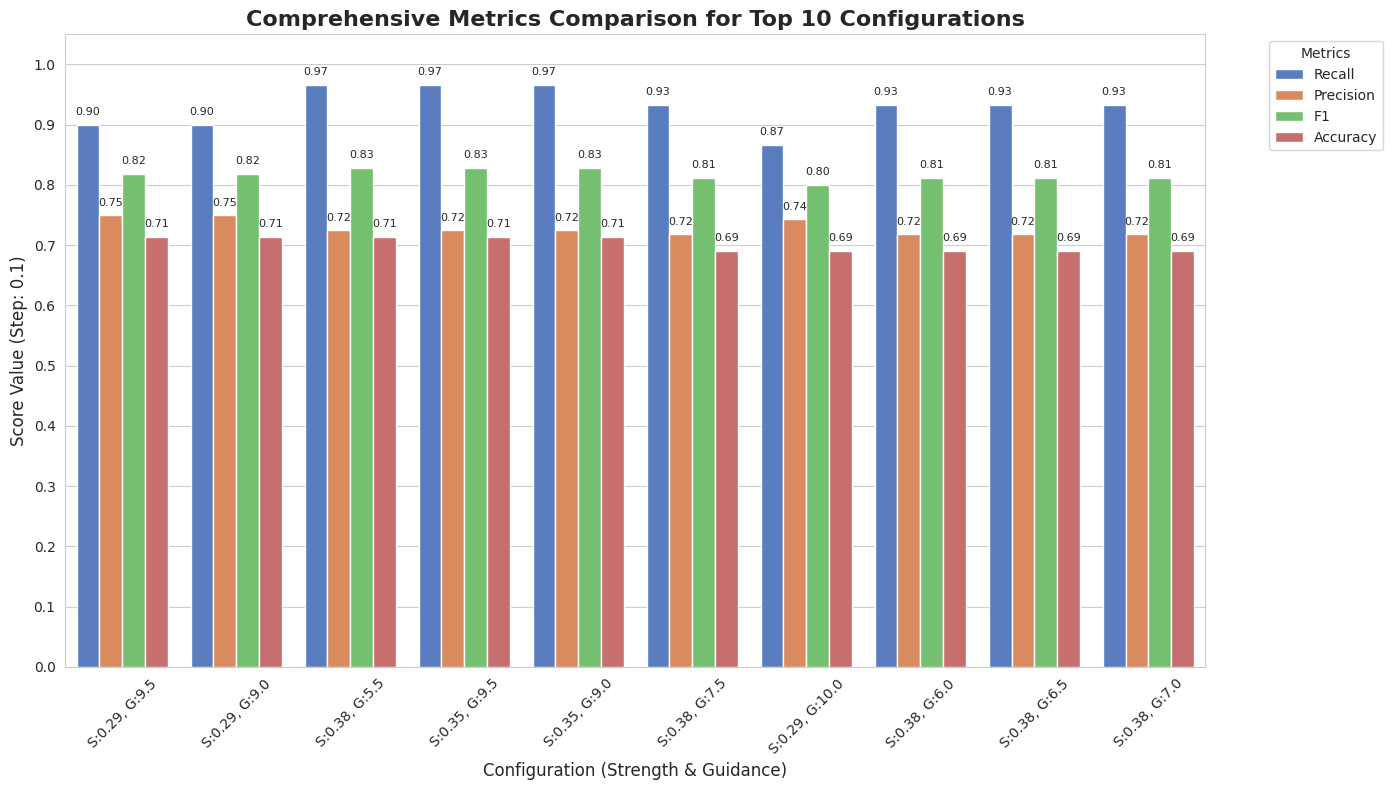

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # نحتاج مكتبة numpy لتوليد الفترات بدقة

# 1. تحميل البيانات من الملف المحدث
df = pd.read_csv('anomaly_detection_results/grid_test/others/all_categories_grid_search.csv')
df.where(df['Category']=="capsule", inplace=True) # التأكد من أن F1 أكبر من 0 لتجنب المشاكل في الرسم

top_n = 10
df_top = df.sort_values(by='F1', ascending=False).head(top_n).copy()

# 2. إنشاء تسمية لكل إعداد (Strength & Guidance)
df_top['Config'] = df_top.apply(lambda x: f"S:{x['Strength']}, G:{x['Guidance']}", axis=1)

# 3. إعادة تشكيل البيانات لتناسب رسم الأعمدة المجمعة
df_melted = df_top.melt(id_vars='Config',
                        value_vars=['Recall', 'Precision', 'F1', 'Accuracy'],
                        var_name='Metric',
                        value_name='Value')

# 4. إعداد الرسم البياني
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid") # التأكد من تفعيل الشبكة البيضاء لظهور الخطوط
barplot = sns.barplot(data=df_melted, x='Config', y='Value', hue='Metric', palette='muted')

# --- التعديل المطلوب هنا ---
# تحديد علامات التدريج (Ticks) لتكون كل 0.1 من 0 إلى 1
plt.yticks(np.arange(0, 1.1, 0.1)) 
# ---------------------------

# إضافة العناوين والتنسيقات
plt.title(f'Comprehensive Metrics Comparison for Top {top_n} Configurations', fontsize=16, fontweight='bold')
plt.xlabel('Configuration (Strength & Guidance)', fontsize=12)
plt.ylabel('Score Value (Step: 0.1)', fontsize=12)
plt.ylim(0, 1.05) # ترك مساحة بسيطة في الأعلى لظهور القيم بوضوح
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# إضافة القيم فوق الأعمدة (Annotations) بدقة بكسلية
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.2f'),
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 9),
                         textcoords='offset points',
                         fontsize=8)

# حفظ الرسم البياني
plt.tight_layout()
# plt.savefig('anomaly_detection_results/top_configs_comparison.png', dpi=300)
print("✅ تم حفظ الرسم البياني المعدل بفاصل 0.1")

In [22]:
import pandas as pd
# Category,AUC,Precision,Recall,F1,Accuracy,Threshold

a=[
"bottle",0.7404761904761905,0.8382352941176471,0.9047619047619048,0.8702290076335878,0.7951807228915663,0.24702552165836095,
"capsule",0.7363382528919027,0.9135802469135802,0.6788990825688074,0.7789473684210526,0.6818181818181818,0.19644147362560033,
"pill",0.5801963993453355,0.8716216216216216,0.9148936170212766,0.8927335640138409,0.8143712574850299,0.23861591527238485,
"toothbrush",0.3194444444444444,0,0.0,0,0.2857142857142857,0.3179715880192816,
]

df = pd.DataFrame([a[i:i+7] for i in range(0, len(a), 7)],
                  columns=['Category', 'AUC', 'Precision', 'Recall', 'F1', 'Accuracy', 'Threshold'])

df.round(2)

,Category,AUC,Precision,Recall,F1,Accuracy,Threshold
0,bottle,0.74,0.84,0.90,0.87,0.80,0.25
1,capsule,0.74,0.91,0.68,0.78,0.68,0.20
2,pill,0.58,0.87,0.91,0.89,0.81,0.24
3,toothbrush,0.32,0.00,0.00,0.00,0.29,0.32
